# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int)

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int)
    
    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
class_counts = np.bincount(y_train, minlength=num_classes)

summary_df = pd.DataFrame({
    "class_index": range(num_classes),
    "class_name": class_names,
    "num_training_samples": class_counts
})

summary_df


,class_index,class_name,num_training_samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4880 - accuracy: 0.8073 - val_loss: 0.2027 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1655 - accuracy: 0.9361 - val_loss: 0.1358 - val_accuracy: 0.9368
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1252 - accuracy: 0.9505 - val_loss: 0.1966 - val_accuracy: 0.9273
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0981 - accuracy: 0.9595 - val_loss: 0.1258 - val_accuracy: 0.9443
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0756 - accuracy: 0.9719 - val_loss: 0.1641 - val_accuracy: 0.9266
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0692 - accuracy: 0.9755 - val_loss: 0.2387 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0602 - accuracy: 0.9767 - val_loss: 0.1413 - val_accuracy: 0.9429
Epoch 8/40
92/92 [==

### Training Curves


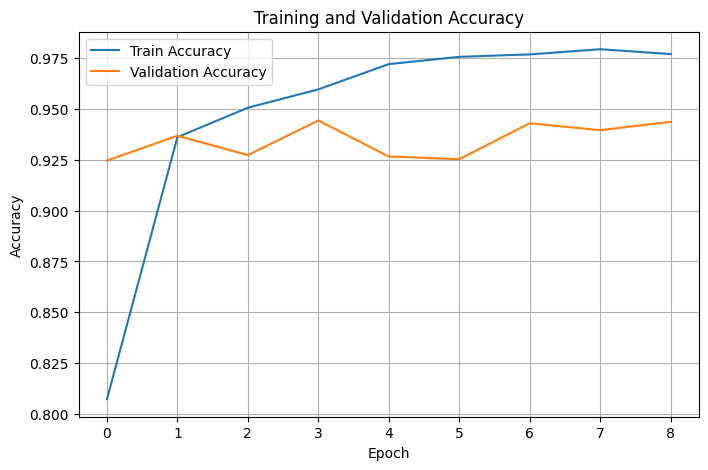

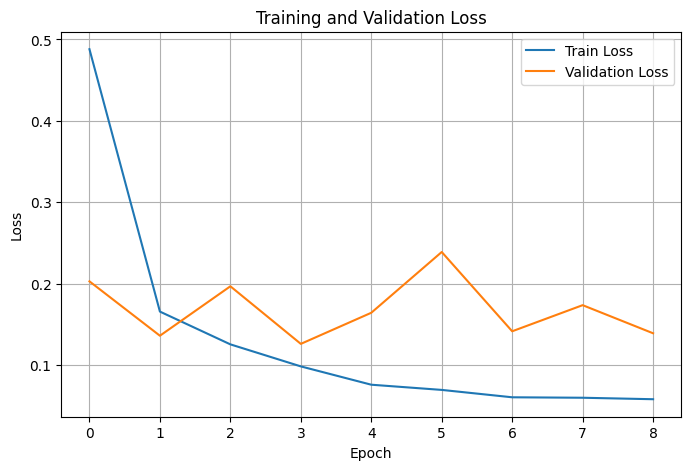

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 786us/step
Test Accuracy: 0.9291

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.90      0.98      0.94       496
  WALKING_UPSTAIRS       0.95      0.88      0.92       471
WALKING_DOWNSTAIRS       0.94      0.92      0.93       420
           SITTING       0.93      0.87      0.90       491
          STANDING       0.86      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



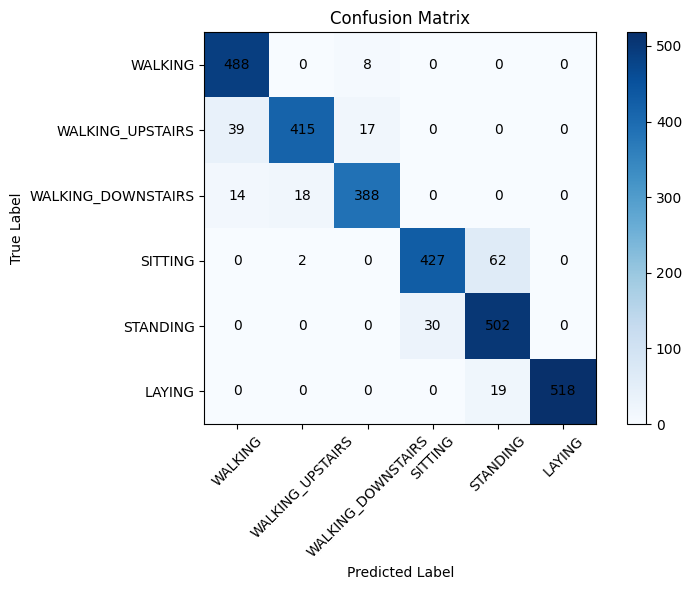

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. predicted probabilities
y_prob = baseline_model.predict(X_test)

# 2. class predictions
y_pred = np.argmax(y_prob, axis=1)

# 3. test accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

# 4. classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = np.round(x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()


def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
# Convert models
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_float16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)

# Save models and get file sizes
fp32_size_kb = save_binary_model(tflite_fp32, "baseline_fp32.tflite")
dynamic_size_kb = save_binary_model(tflite_dynamic, "baseline_dynamic.tflite")
float16_size_kb = save_binary_model(tflite_float16, "baseline_float16.tflite")
int8_size_kb = save_binary_model(tflite_int8, "baseline_int8.tflite")

# Evaluate models
fp32_acc, fp32_pred = evaluate_tflite_model(tflite_fp32, X_test, y_test)
dynamic_acc, dynamic_pred = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
float16_acc, float16_pred = evaluate_tflite_model(tflite_float16, X_test, y_test)
int8_acc, int8_pred = evaluate_tflite_model(tflite_int8, X_test, y_test)

# Summarize results
results = pd.DataFrame({
    "model": ["FP32", "Dynamic Range", "Float16", "INT8"],
    "size_kb": [fp32_size_kb, dynamic_size_kb, float16_size_kb, int8_size_kb],
    "test_accuracy": [fp32_acc, dynamic_acc, float16_acc, int8_acc]
})

results


INFO:tensorflow:Assets written to: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpy0br9npp/assets


INFO:tensorflow:Assets written to: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpy0br9npp/assets


INFO:tensorflow:Assets written to: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpkpffa9a7/assets


2026-04-21 14:24:24.517295: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 14:24:24.517310: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 14:24:24.517643: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpy0br9npp
2026-04-21 14:24:24.518098: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 14:24:24.518102: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpy0br9npp
2026-04-21 14:24:24.519415: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-21 14:24:24.519825: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 14:24:24.543946: I tensorflow/cc/saved_model/loader.

INFO:tensorflow:Assets written to: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmphhpzqvch/assets


2026-04-21 14:24:24.868409: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 14:24:24.868419: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 14:24:24.868515: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpkpffa9a7
2026-04-21 14:24:24.868954: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 14:24:24.868958: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpkpffa9a7
2026-04-21 14:24:24.871026: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 14:24:24.891810: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpkpffa9a7
2026-04-

INFO:tensorflow:Assets written to: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpvdb65c_y/assets


INFO:tensorflow:Assets written to: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpvdb65c_y/assets
/Users/fanyinuo/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-21 14:24:25.520887: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 14:24:25.520897: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 14:24:25.520997: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpvdb65c_y
2026-04-21 14:24:25.521412: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 14:24:25.521416: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2z/7_d3p4lj1fl_

,model,size_kb,test_accuracy
0,FP32,726.718750,0.929080
1,Dynamic Range,186.109375,0.929759
2,Float16,365.710938,0.929080
3,INT8,185.335938,0.930438


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
comparison_df = pd.DataFrame({
    "Model Family": ["Baseline", "Baseline", "Baseline", "Baseline"],
    "Format": ["FP32 TFLite", "Dynamic Range TFLite", "Float16 TFLite", "INT8 TFLite"],
    "Test Accuracy": [fp32_acc, dynamic_acc, float16_acc, int8_acc],
    "Model Size (KB)": [fp32_size_kb, dynamic_size_kb, float16_size_kb, int8_size_kb]
})

comparison_df


,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.929080,726.718750
1,Baseline,Dynamic Range TFLite,0.929759,186.109375
2,Baseline,Float16 TFLite,0.929080,365.710938
3,Baseline,INT8 TFLite,0.930438,185.335938


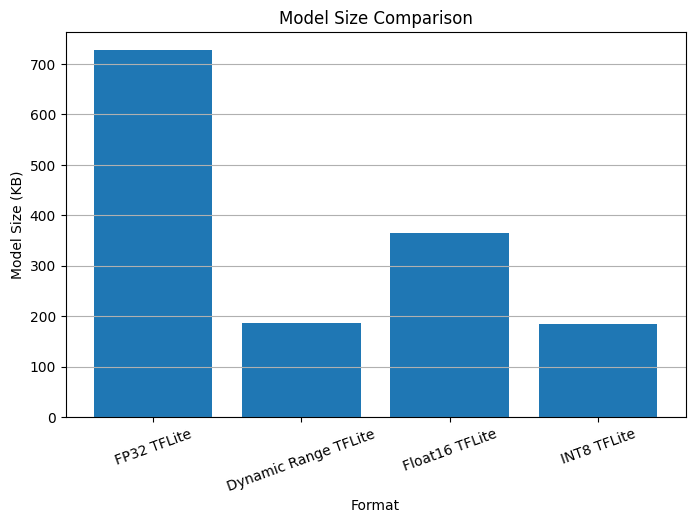

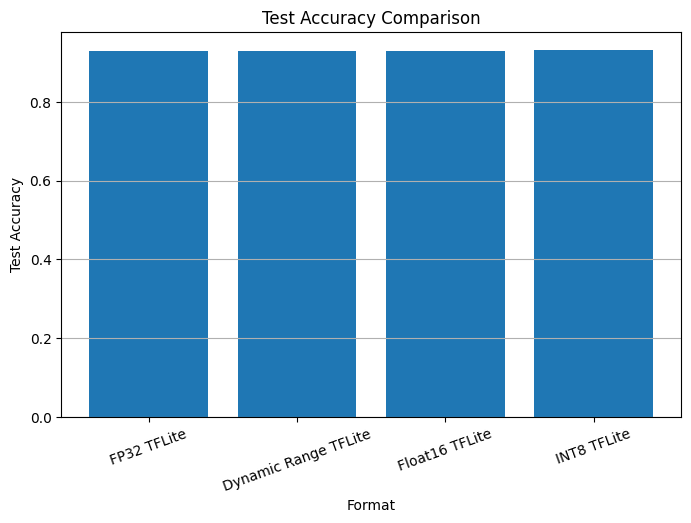

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
# Bar plot for model size
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
plt.xlabel("Format")
plt.ylabel("Model Size (KB)")
plt.title("Model Size Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

# Bar plot for test accuracy
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
plt.xlabel("Format")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

### Confusion Matrix for the PTQ Int8 Model


PTQ INT8 Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.90      0.98      0.94       496
  WALKING_UPSTAIRS       0.95      0.89      0.92       471
WALKING_DOWNSTAIRS       0.94      0.92      0.93       420
           SITTING       0.93      0.88      0.90       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



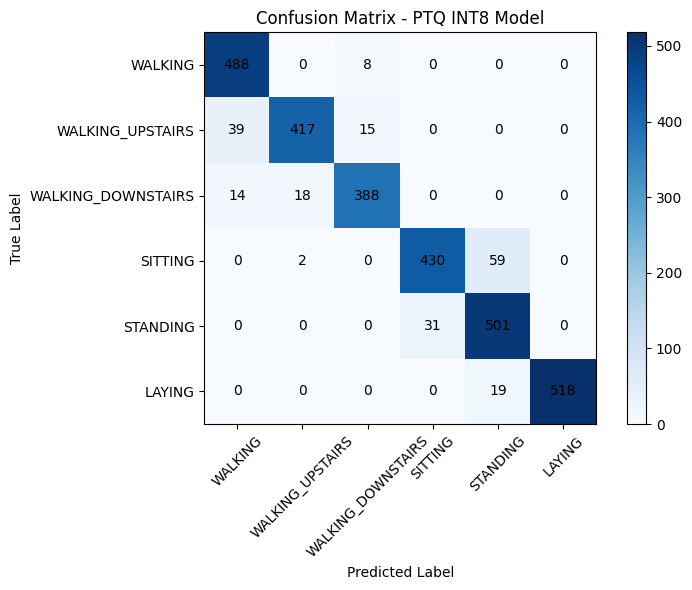

In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Classification report
print("PTQ INT8 Classification Report:")
print(classification_report(y_test, int8_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, int8_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - PTQ INT8 Model")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0670 - accuracy: 0.9801 - val_loss: 0.1311 - val_accuracy: 0.9415
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0550 - accuracy: 0.9816 - val_loss: 0.1250 - val_accuracy: 0.9436
Epoch 3/8
92/92 [==============================] - 0s 3ms/step - loss: 0.0515 - accuracy: 0.9823 - val_loss: 0.1385 - val_accuracy: 0.9415
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0481 - accuracy: 0.9847 - val_loss: 0.1239 - val_accuracy: 0.9449
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0455 - accuracy: 0.9842 - val_loss: 0.1569 - val_accuracy: 0.9429
Epoch 6/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0439 - accuracy: 0.9859 - val_loss: 0.1487 - val_accuracy: 0.9443
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0441 - accuracy: 0.9855 - val_loss: 0.1315 - val_accuracy: 0.9429
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
# Evaluate test accuracy
test_loss, test_acc = qat_model.evaluate(X_test, y_test, verbose=0)
print(f"QAT Keras Test Accuracy: {test_acc:.4f}")

# Predict classes
y_qat_prob = qat_model.predict(X_test)
y_qat_pred = np.argmax(y_qat_prob, axis=1)

# Classification report
print("\nQAT Keras Classification Report:")
print(classification_report(y_test, y_qat_pred, target_names=class_names))

QAT Keras Test Accuracy: 0.9281
93/93 [==============================] - 0s 525us/step

QAT Keras Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.93      0.95      0.94       496
  WALKING_UPSTAIRS       0.95      0.92      0.93       471
WALKING_DOWNSTAIRS       0.92      0.94      0.93       420
           SITTING       0.95      0.85      0.90       491
          STANDING       0.84      0.96      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#

qat_tflite_int8 = convert_to_tflite_int8(qat_model)

qat_int8_size_kb = save_binary_model(qat_tflite_int8, "qat_int8.tflite")

qat_int8_acc, qat_int8_pred = evaluate_tflite_model(qat_tflite_int8, X_test, y_test)

print(f"QAT INT8 TFLite Model Size: {qat_int8_size_kb:.2f} KB")
print(f"QAT INT8 TFLite Test Accuracy: {qat_int8_acc:.4f}")

INFO:tensorflow:Assets written to: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpnzuxv0_c/assets


INFO:tensorflow:Assets written to: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpnzuxv0_c/assets
/Users/fanyinuo/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


QAT INT8 TFLite Model Size: 185.70 KB
QAT INT8 TFLite Test Accuracy: 0.9281


2026-04-21 14:24:28.894974: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-21 14:24:28.894984: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-21 14:24:28.895092: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpnzuxv0_c
2026-04-21 14:24:28.896082: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-21 14:24:28.896086: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpnzuxv0_c
2026-04-21 14:24:28.898832: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-21 14:24:28.931291: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/2z/7_d3p4lj1fl_fpd2mxnjb51h0000gn/T/tmpnzuxv0_c
2026-04-

## 12. PTQ Int8 vs QAT Int8


In [21]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_vs_qat_df = pd.DataFrame({
    "Model": ["PTQ INT8", "QAT INT8"],
    "Test Accuracy": [int8_acc, qat_int8_acc],
    "Model Size (KB)": [int8_size_kb, qat_int8_size_kb]
})

ptq_vs_qat_df

,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.930438,185.335938
1,QAT INT8,0.928062,185.695312


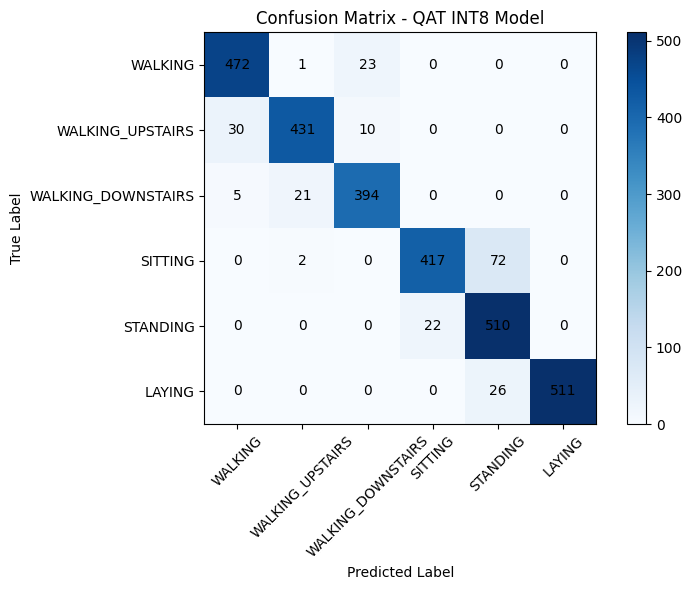

In [22]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
cm = confusion_matrix(y_test, qat_int8_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - QAT INT8 Model")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
   The INT8 TensorFlow Lite model gave the smallest model size.
   
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
   The INT8 TensorFlow Lite model gave the best accuracy among the TensorFlow Lite models, with a test accuracy of about 0.9304.

3. Did QAT improve the final int8 model compared with PTQ int8?
   No. In my results, QAT did not improve the final int8 model compared with PTQ int8. PTQ INT8 achieved slightly higher test accuracy (0.9304 vs. 0.9281) and was also slightly smaller (185.34 KB vs. 185.70 KB).
   
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
   This dataset is a good fit because it uses fixed-length numerical sensor features and has only six activity classes, so a small dense neural network can learn the patterns effectively. It is also well suited for compression and TensorFlow Lite conversion, which makes it practical for TinyML deployment.
   
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
   I would choose the PTQ INT8 model because it provides the best tradeoff between model size and accuracy in my results. It has the highest test accuracy while also being the smallest model, which makes it the most suitable choice for a resource-constrained device.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
